# Ejercicio 8.1 - Extension espacial de valores altos de cianobacteria

Este cuaderno calcula, para cada una de las 22 escenas oficiales, que
porcentaje del area valida del lago supera un umbral fijo de "valor alto"
de cianobacteria, y grafica esa extension a lo largo del tiempo por lago.

Lee los raster de cianobacteria ya exportados por el ejercicio 3 y la
mascara combinada (geometria real ^ SCL-agua) del ejercicio 5; la logica
vive en `src/analisis_espacial.py`, este cuaderno solo la orquesta.

## Decision documentada antes de ver los resultados

**Umbral de "valor alto": 10 ug/L**, correspondiente al "Alert Level 1" de
las guias de la OMS (WHO, 2003), *Guidelines for Safe Recreational Water
Environments*, Volumen 1, Capitulo 8 (clorofila-a asociada a dominancia de
cianobacterias). Es un umbral de salud publica externo a este conjunto de
datos, fijado en `src/config.py` (`UMBRAL_CIANOBACTERIA_ALTO_UGL`) antes de
calcular que porcentaje de cada lago queda por encima, para no elegirlo
segun que tan llamativo se vea el resultado.

**Area de pixel**: el CRS de salida de los raster ya es UTM
(`EPSG:32615`, metros), por lo que el area de un pixel es simplemente
`resolucion_m ** 2` (10 m x 10 m = 100 m^2); no hace falta una rejilla de
area equivalente adicional.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raiz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src import analisis_espacial as ae
from src.config import LAGOS, UMBRAL_CIANOBACTERIA_ALTO_UGL, RESOLUCION_OBJETIVO_M

print(f'Raiz del proyecto: {ROOT}')
print(f'Umbral de valor alto: {UMBRAL_CIANOBACTERIA_ALTO_UGL} ug/L')
print(f'Area de pixel: {ae.pixel_area_m2(RESOLUCION_OBJETIVO_M)} m2 (resolucion {RESOLUCION_OBJETIVO_M} m)')

Raiz del proyecto: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales
Umbral de valor alto: 10.0 ug/L
Area de pixel: 100.0 m2 (resolucion 10 m)


## 1. Calcular extension de valores altos para las 22 escenas

Por escena: `porcentaje_alto = 100 * area_alta_valida / area_valida_del_lago`,
usando solo pixeles que pasan la mascara combinada (geometria real del
lago ^ mascara SCL-agua de esa escena). Se reporta junto la cobertura
valida total y el `quality_flag` heredado del manifiesto de indices, para
que una escena de cobertura parcial no aparente una floracion menor.

In [2]:
filas = ae.build_extension_floracion()
tabla = pd.DataFrame(filas)
display(tabla)

path = ae.write_extension_floracion(filas)
print(f'{len(filas)} filas escritas en {path}')

,lago,fecha,umbral_alto_ugl,resolucion_m,area_pixel_m2,pixeles_validos_lago,pixeles_altos,area_valida_m2,area_alta_m2,porcentaje_alto,cobertura_valida_pct,quality_flag
0,amatitlan,2025-01-28,10.0,10.0,100.0,144693,11,14469300.0,1100.0,0.0076,11.751,calculado
1,amatitlan,2025-04-15,10.0,10.0,100.0,143376,933,14337600.0,93300.0,0.6507,11.6167,calculado
2,amatitlan,2025-04-28,10.0,10.0,100.0,143348,10646,14334800.0,1064600.0,7.4267,11.6173,calculado
3,amatitlan,2025-11-24,10.0,10.0,100.0,144566,2929,14456600.0,292900.0,2.0261,11.6998,calculado
4,amatitlan,2026-01-08,10.0,10.0,100.0,144419,10729,14441900.0,1072900.0,7.4291,11.7581,calculado
5,amatitlan,2026-02-02,10.0,10.0,100.0,142415,2,14241500.0,200.0,0.0014,11.5348,calculado
6,amatitlan,2026-02-07,10.0,10.0,100.0,144515,33,14451500.0,3300.0,0.0228,11.7192,cobertura_parcial_oficial
7,amatitlan,2026-03-29,10.0,10.0,100.0,144892,11145,14489200.0,1114500.0,7.6919,11.7492,calculado
8,amatitlan,2026-04-13,10.0,10.0,100.0,145470,6334,14547000.0,633400.0,4.3542,11.804,calculado
9,amatitlan,2026-04-28,10.0,10.0,100.0,137631,49963,13763100.0,4996300.0,36.3021,11.2027,calculado


22 filas escritas en C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\results\tables\extension_floracion.csv


## 2. Extension temporal por lago

Serie de `porcentaje_alto` por fecha, un grafico por lago. Las fechas de
cobertura parcial se marcan aparte para no leerse con la misma
confiabilidad que una escena completa.

In [3]:
for lago in LAGOS:
    out_path = ae.save_extension_floracion_figure(lago, filas)
    print(f'{lago}: {out_path}')

atitlan: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\results\figures\atitlan_extension_floracion.png
amatitlan: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\results\figures\amatitlan_extension_floracion.png


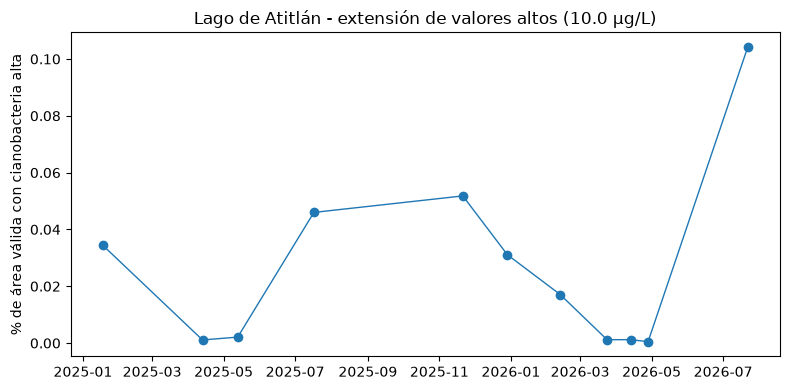

In [4]:
import matplotlib.pyplot as plt

fig = ae.plot_extension_floracion_series('atitlan', filas)
plt.show()

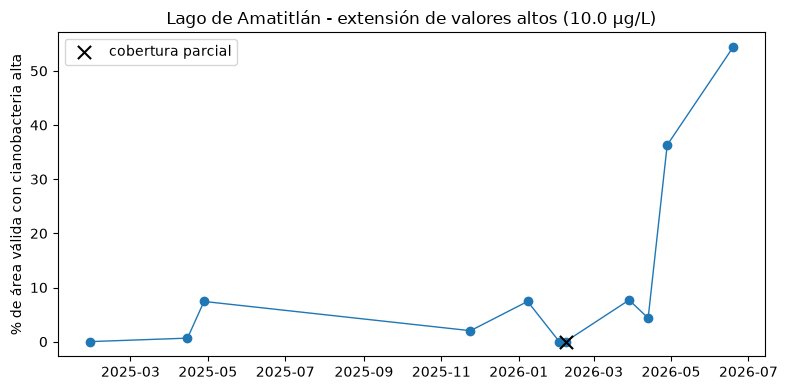

In [5]:
fig = ae.plot_extension_floracion_series('amatitlan', filas)
plt.show()

## 3. Comparacion directa entre lagos

Ambos lagos usan el mismo umbral, la misma formula de area de pixel y la
misma mascara combinada, por lo que es valido compararlos en un solo eje.

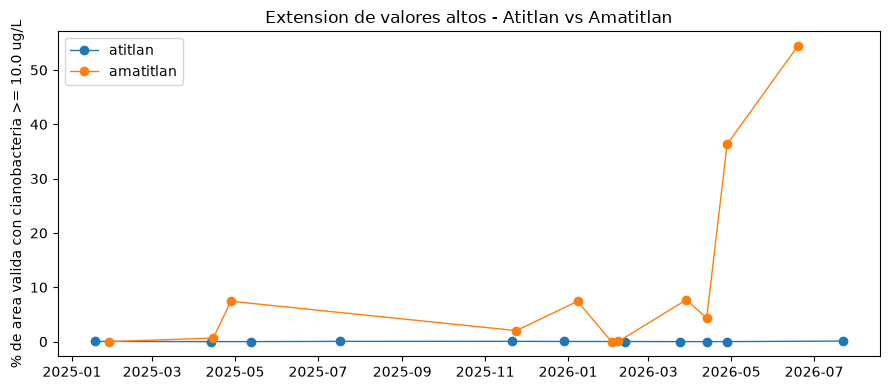

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for lago in LAGOS:
    serie = tabla[tabla['lago'] == lago].copy()
    serie['fecha'] = pd.to_datetime(serie['fecha'])
    serie = serie.sort_values('fecha')
    serie['porcentaje_alto'] = serie['porcentaje_alto'].astype(float)
    ax.plot(serie['fecha'], serie['porcentaje_alto'], marker='o', linewidth=1, label=lago)
ax.set_ylabel(f'% de area valida con cianobacteria >= {UMBRAL_CIANOBACTERIA_ALTO_UGL} ug/L')
ax.set_title('Extension de valores altos - Atitlan vs Amatitlan')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Resultado del ejercicio

- `results/tables/extension_floracion.csv` tiene las 22 filas (11 por
  lago) con porcentaje de area alta, area valida total, cobertura valida
  y `quality_flag` heredado del manifiesto de indices.
- `results/figures/atitlan_extension_floracion.png` y
  `results/figures/amatitlan_extension_floracion.png` grafican la
  extension a lo largo del tiempo por lago.
- El umbral (10 ug/L, WHO Alert Level 1) y el area de pixel (100 m^2,
  `resolucion_m ** 2`) quedan documentados en `src/config.py` y en
  `codebook.md`.
- La extension de Amatitlan crece de forma marcada en las ultimas fechas
  de la serie (coincide con los picos ya identificados en el ejercicio 4);
  Atitlan se mantiene con una extension de valores altos minima durante
  todo el periodo.